# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [1]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [2]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images.astype("float32") / 255.0  # Normalize on the fly or pre-normalize
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx]
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [3]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

Loading data from: /Users/sara/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [4]:
print(images.shape)

(100000, 96, 96, 3)


In [5]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

# train_images = images[:8000]
# val_images = images[8000:9000]
# test_images = images[9000:]


In [6]:
train_generator = PatchGenerator(train_images, batch_size=8)
val_generator = PatchGenerator(val_images, batch_size=8)
test_generator = PatchGenerator(test_images, batch_size=8)

Let us inspect the dataset.

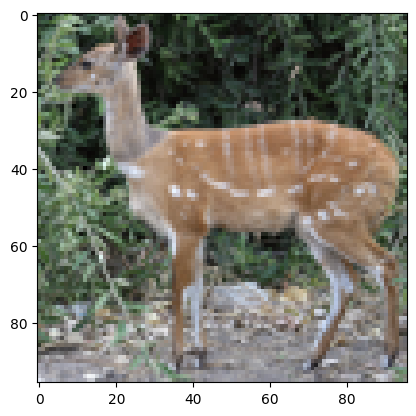

In [7]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [9]:
a,b = test_generator.__getitem__(1)

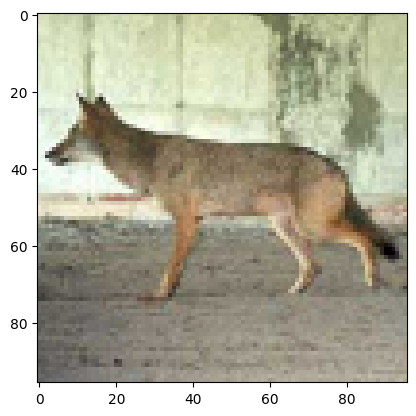

In [10]:
plt.imshow(b[4])

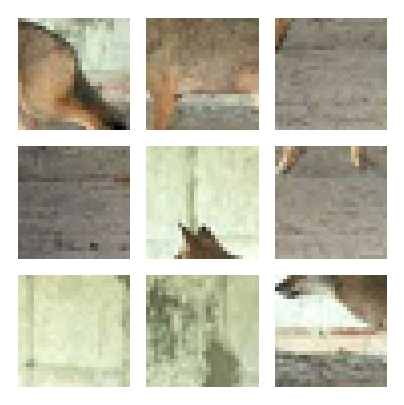

In [11]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [12]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [13]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.18264844, shape=(), dtype=float32)
std: tf.Tensor(0.0008966694, shape=(), dtype=float32)


In [14]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers


# def build_patch_encoder():

#     inp = keras.Input((28,28,3))

#     x = layers.Conv2D(32,3,padding="same")(inp)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.Conv2D(32,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(64,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.Conv2D(64,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(128,3,padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.ReLU()(x)

#     x = layers.GlobalAveragePooling2D()(x)

#     x = layers.Dense(256)(x)

#     return keras.Model(inp,x)

In [15]:
# class TransformerBlock(layers.Layer):

#     def __init__(self,
#                  dim=256,
#                  heads=8,
#                  ff_dim=512,
#                  dropout=0.1):

#         super().__init__()

#         self.att = layers.MultiHeadAttention(
#             num_heads=heads,
#             key_dim=dim//heads
#         )

#         self.ff = keras.Sequential([
#             layers.Dense(ff_dim,activation="gelu"),
#             layers.Dropout(dropout),
#             layers.Dense(dim)
#         ])

#         self.norm1 = layers.LayerNormalization()
#         self.norm2 = layers.LayerNormalization()

#     def call(self,x):

#         a = self.att(x,x)

#         x = self.norm1(x+a)

#         f = self.ff(x)

#         x = self.norm2(x+f)

#         return x

In [16]:
# def build_model():

#     inp = keras.Input((9,28,28,3))

#     encoder = build_patch_encoder()

#     tokens = layers.TimeDistributed(
#         encoder
#     )(inp)

#     tokens = TransformerBlock()(tokens)
#     tokens = TransformerBlock()(tokens)
#     tokens = TransformerBlock()(tokens)

#     position_logits = layers.Dense(9)(tokens)

#     position_probs = layers.Softmax(axis=-1)(position_logits)

#     grid = layers.Lambda(
#         lambda z: tf.matmul(
#             z[0],
#             z[1],
#             transpose_a=True
#         )
#     )([position_probs,tokens])

#     grid = layers.Reshape((3,3,256))(grid)


#     x = layers.Conv2D(256,3,padding="same",activation="relu")(grid)

#     x = layers.UpSampling2D()(x)  # 6×6
#     x = layers.Conv2D(256,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 12×12
#     x = layers.Conv2D(128,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 24×24
#     x = layers.Conv2D(128,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 48×48
#     x = layers.Conv2D(64,3,padding="same",activation="relu")(x)

#     x = layers.UpSampling2D()(x)  # 96×96
#     x = layers.Conv2D(32,3,padding="same",activation="relu")(x)

#     out = layers.Conv2D(3,1,activation="sigmoid")(x)

#     return keras.Model(inp,out)

In [17]:
# x, y = train_generator[0]
# print(x.shape, y.shape)

In [18]:
# model = build_model()

# model.compile(
#     optimizer=keras.optimizers.Adam(1e-3),
#     loss="mae"
# )

# model.summary()

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# -------------------------------------------------------------
# 1. KEEP OR IMPROVE PATCH ENCODER (as allowed)
# -------------------------------------------------------------
def build_patch_encoder():
    inp = keras.Input((28, 28, 3))

    x = layers.Conv2D(32, 3, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256)(x)
    return keras.Model(inp, x, name="patch_encoder")

# -------------------------------------------------------------
# 2. STANDARD TRANSFORMER BLOCK
# -------------------------------------------------------------
class TransformerBlock(layers.Layer):
    def __init__(self, dim=256, heads=8, ff_dim=512, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=heads, key_dim=dim // heads)
        self.ff = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim)
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

    def call(self, x):
        a = self.att(x, x)
        x = self.norm1(x + a)
        f = self.ff(x)
        x = self.norm2(x + f)
        return x

# -------------------------------------------------------------
# 3. COMPLETE REWRITTEN MODEL (Under 6M Params)
# -------------------------------------------------------------
def build_model():
    # Input shape: (Batch, 9 patches, 28, 28, 3)
    inp = keras.Input((9, 28, 28, 3))
    
    # Step 1: Encode Patches independently
    encoder = build_patch_encoder()
    tokens = layers.TimeDistributed(encoder)(inp) # Shape: (Batch, 9, 256)
    
    # Step 2: Contextualize scrambled patches via self-attention
    tokens = TransformerBlock(dim=256, heads=8, ff_dim=512)(tokens)
    tokens = TransformerBlock(dim=256, heads=8, ff_dim=512)(tokens)

    # Step 3: Create 9 Target Position Grid Queries 
    # This acts as a template for the target 3x3 layout (Top-Left to Bottom-Right)
    grid_queries = layers.Embedding(input_dim=9, output_dim=256)(tf.range(9))
    
    # FIX: Pass both tensors to Lambda so it can dynamically tile across the batch size
    grid_queries = layers.Lambda(
        lambda x: tf.tile(x[0][None, :, :], [tf.shape(x[1])[0], 1, 1])
    )([grid_queries, tokens])

    # Step 4: Cross-Attention
    # Queries = Target positions (ordered 0-8)
    # Keys/Values = Encoded scrambled patch tokens
    cross_attention = layers.MultiHeadAttention(num_heads=8, key_dim=256 // 8)
    grid_mapped = cross_attention(query=grid_queries, value=tokens, key=tokens)
    grid_mapped = layers.LayerNormalization()(grid_mapped + grid_queries)

    # Step 5: Convert the ordered tokens into a 3x3 Grid
    grid = layers.Reshape((3, 3, 256))(grid_mapped)

    # Step 6: Powerful Fully-Convolutional Image Decoder Head
    x = layers.Conv2D(256, 3, padding="same")(grid)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 3x3 -> 6x6
    x = layers.UpSampling2D(size=(2, 2))(x)  
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 6x6 -> 12x12
    x = layers.UpSampling2D(size=(2, 2))(x)  
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 12x12 -> 24x24
    x = layers.UpSampling2D(size=(2, 2))(x)  
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 24x24 -> 48x48
    x = layers.UpSampling2D(size=(2, 2))(x)  
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 48x48 -> 96x96
    x = layers.UpSampling2D(size=(2, 2))(x)  
    x = layers.Conv2D(32, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Final Output Layer (Produces 96x96x3 image normalized between 0.0 and 1.0)
    out = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

    return keras.Model(inp, out)

# Instantiate the model
model = build_model()

# Compile using MAE as required by your project instructions
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mae"
)

# Explicitly print parameter count to prove it's under 6 Million
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 256)    │    173,728 │ input_layer[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block   │ (None, 9, 256)    │    527,104 │ time_distributed… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 9, 256)    │    527,104 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 9, 256)    │          0 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 256)    │    263,168 │ transformer_bloc… │
│ (MultiHeadAttentio… │                   │            │ lambda[0][0],     │
│                     │                   │            │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 256)    │          0 │ multi_head_atten… │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 9, 256)    │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 3, 3, 256) │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 3, 3, 256) │    590,080 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 3, 256) │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 3, 3, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 6, 6, 256) │          0 │ re_lu_5[0][0]     │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 6, 6, 128) │    295,040 │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 6, 128) │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_6 (ReLU)      │ (None, 6, 6, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 12, 12,    │          0 │ re_lu_6[0][0]     │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 12, 12,    │    147,584 │ up_sampling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,629,251 (10.03 MB)

 Trainable params: 2,627,331 (10.02 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [20]:
x, y = train_generator[0]
print(x.shape, y.shape)

(8, 9, 28, 28, 3) (8, 96, 96, 3)


In [21]:


history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 661s 66ms/step - loss: 0.2025 - val_loss: 0.1950
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 663s 66ms/step - loss: 0.1994 - val_loss: 0.2013
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 654s 65ms/step - loss: 0.1998 - val_loss: 0.1986
Epoch 4/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 658s 66ms/step - loss: 0.1995 - val_loss: 0.1992
Epoch 5/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 647s 65ms/step - loss: 0.1984 - val_loss: 0.1923
Epoch 6/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 646s 65ms/step - loss: 0.1951 - val_loss: 0.1929
Epoch 7/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 647s 65ms/step - loss: 0.1963 - val_loss: 0.1900
Epoch 8/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 654s 65ms/step - loss: 0.1944 - val_loss: 0.1920
Epoch 9/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 649s 65ms/step - loss: 0.1931 - val_loss: 0.1891
Epoch 10/10
 6121/10000 ━━━━━━━━━━━━━━━━━━━━ 4:04 63ms/step - loss: 0.1928

KeyboardInterrupt: 

In [ ]:
import numpy as np
import tensorflow as tf

mae_metric = tf.keras.metrics.MeanAbsoluteError()
mae_values = []

for i in range(len(test_generator)):
    x, y = test_generator[i]
    pred = model.predict(x, verbose=0)

    mae_metric.update_state(y, pred)
    mae_values.append(tf.reduce_mean(tf.abs(y - pred)))

print("MAE:", mae_metric.result().numpy())
print("STD:", tf.math.reduce_std(mae_values).numpy())



In [ ]:
model.save("jigsaw_model.keras")

# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.



